# Exp CASCATA — Fatoração Completa por Colapso Orbital Iterado

**T. Bandeira · Junho de 2026**
*Série analise-espectral-primos — continuação de Exp Detector (Nota 36)*

---

## Hipótese central

Dois rounds de colapso orbital ("cascata") permitem a **fatoração prima completa**
de um lote de candidatos sem nenhuma operação aritmética sobre eles:

- **Stage 1:** remove $P_1 = \{2,3,5,7\}$, detecta cofatores $q$ (primos → encerrado;
  compostos → Stage 2).
- **Stage 2:** para cada cofator composto $q$, subtrai $\log p$ **uma vez** do resíduo
  do Stage 1 (sendo $p$ o menor primo de $q$). Todos os membros do grupo convergem
  para $f_{q/p}$ — se $q/p$ é primo, $q = p \times (q/p)$ está fatorado.

**Ponto crítico do Stage 2:** a operação é "subtrair $\log p$ uma vez",
**não** substituir a base por $P_1 \cup \{p\}$. Substituir a base removeria
TODOS os fatores de $p$ — incorreto para potências primas como $11^2$.
A subtração de uma cópia preserva a estrutura: $\log(11^2) - \log(11) = \log(11)$,
revelando que o cofator remanescente ainda é 11 (quadrado perfeito).


## 1. Setup

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from sympy import isprime, factorint
import pandas as pd

T_MAX = 6500.0
DT    = 0.05
W     = 5

t     = np.arange(0.1, T_MAX, DT)
freqs = np.fft.rfftfreq(len(t), d=DT)
print(f'Pontos: {len(t):,}  |  Delta_f = {freqs[1]:.6f}')

BG      = '#0D0D1A'
C_S1    = '#7EB8F7'   # azul  — Stage 1
C_S2A   = '#A8E6CF'   # verde — Stage 2a (cofator 143)
C_S2B   = '#DDA0DD'   # lila  — Stage 2b (cofator 121)
C_CTRL  = '#FFB347'   # laranja — controle (primos diretos)
C_GRID  = '#1E1E3A'
C_TEXT  = '#CCCCDD'

P1 = [2, 3, 5, 7]

def v_q(m, q):
    v = 0
    while m % q == 0:
        v += 1; m //= q
    return v

def log_res(m, qs):
    lr = math.log(m)
    for q in qs:
        lr -= v_q(m, q) * math.log(q)
    return lr

def cofator(m, qs):
    lr = log_res(m, qs)
    return 1 if lr < 1e-9 else round(math.exp(lr))

def amp_em_f(F, f_alvo, w=W):
    idx = np.argmin(np.abs(freqs - f_alvo))
    return np.max(F[max(0,idx-w):min(len(F),idx+w)])

def espectro(sinal):
    return np.abs(np.fft.rfft(sinal)) * DT

def construir_sinal_stage1(grupo):
    """Stage 1: colapso com P1."""
    R = np.zeros(len(t))
    for m in grupo:
        lr = log_res(m, P1)
        if lr > 1e-9:
            R += -np.cos(t * lr) / math.sqrt(lr)
    return R

def construir_sinal_stage2(grupo, p):
    """Stage 2: parte do residuo Stage1, subtrai log(p) UMA VEZ.
    Correto para potencias primas: log(11^2) - log(11) = log(11), nao zero.
    """
    R = np.zeros(len(t))
    for m in grupo:
        lr1 = log_res(m, P1)    # residuo Stage 1
        lr2 = lr1 - math.log(p) # subtrai log(p) uma vez
        if lr2 > 1e-9:
            R += -np.cos(t * lr2) / math.sqrt(lr2)
    return R

# Calibracao empirica
amp_iso = {}
for q in [11, 13, 17, 121, 143]:
    R = -np.cos(t * math.log(q)) / math.sqrt(math.log(q))
    F = espectro(R)
    amp_iso[q] = amp_em_f(F, math.log(q)/(2*math.pi))

print('Setup concluido.')
print(f'amp_iso calibradas: {amp_iso}')


Pontos: 129,998  |  Delta_f = 0.000154
Setup concluido.
amp_iso calibradas: {11: np.float64(1592.2012274190938), 13: np.float64(1495.175238687884), 17: np.float64(1917.1027956820622), 121: np.float64(1385.2825366047564), 143: np.float64(1457.972478189916)}


## 2. Design dos candidatos

| grupo | candidatos | cofator Stage 1 | fatoracao esperada |
|---|---|---|---|
| Grupo 1 | 286, 429, 572, 715, 1001 | **143 = 11·13** (composto) | 2·11·13, 3·11·13, 4·11·13, 5·11·13, 7·11·13 |
| Grupo 2 | 242, 363, 484 | **121 = 11²** (composto) | 2·11², 3·11², 4·11² |
| Controle | 22, 34 | **11, 17** (primos) | 2·11, 2·17 |

**Por que 143 e 121?**
Ambos têm fatores $\geq 11$ (fora de $P_1$), logo sobrevivem ao Stage 1 como cofatores compostos.
A resolução espectral para $T_{\max}=6500$ é suficiente:
$f_{143}$ vs $f_{142}$: 7.3 bins de separação (mínimo exigido: 6).


In [2]:
GRUPO1   = [286, 429, 572, 715, 1001]  # cofator 143 = 11*13
GRUPO2   = [242, 363, 484]              # cofator 121 = 11^2
CONTROLE = [22, 34]                     # cofatores 11, 17 (primos diretos)
TODOS    = GRUPO1 + GRUPO2 + CONTROLE

print('Candidatos e suas fatorizacoes:')
print(f'{"m":>5}  {"fatoracao":>24}  {"cofator_P1":>12}')
for m in TODOS:
    cf = cofator(m, P1)
    fat = str(dict(factorint(m)))
    print(f'{m:>5}  {fat:>24}  {cf:>12}')


Candidatos e suas fatorizacoes:
    m                 fatoracao    cofator_P1
  286      {2: 1, 11: 1, 13: 1}           143
  429      {3: 1, 11: 1, 13: 1}           143
  572      {2: 2, 11: 1, 13: 1}           143
  715      {5: 1, 11: 1, 13: 1}           143
 1001      {7: 1, 11: 1, 13: 1}           143
  242             {2: 1, 11: 2}           121
  363             {3: 1, 11: 2}           121
  484             {2: 2, 11: 2}           121
   22             {2: 1, 11: 1}            11
   34             {2: 1, 17: 1}            17


## 3. Stage 1 — Colapso com $P_1 = \{2,3,5,7\}$

Todos os 10 candidatos colapsam simultaneamente.
Esperamos 4 picos distintos: $f_{143}$ (5×), $f_{121}$ (3×), $f_{11}$ (1×), $f_{17}$ (1×).
Os dois primeiros são compostos e requerem Stage 2.


In [3]:
print('Construindo sinal Stage 1...')
F1 = espectro(construir_sinal_stage1(TODOS))

print()
print(f'  {"cofator":>8}  {"primo":>6}  {"amp":>10}  {"razao":>8}  {"status":>12}')
print('  ' + '-'*52)

resultado_s1 = {}
for cf, exp in [(143,5),(121,3),(11,1),(17,1)]:
    fq    = math.log(cf)/(2*math.pi)
    a     = amp_em_f(F1, fq)
    ratio = a / amp_iso[cf]
    primo = isprime(cf)
    status = 'PRIMO OK' if primo else 'COMPOSTO -> S2'
    resultado_s1[cf] = {'amp':a,'ratio':ratio,'primo':primo}
    print(f'  {cf:>8}  {str(primo):>6}  {a:>10.2f}  {ratio:>8.5f}  {status:>12}')

compostos_s1 = [cf for cf,r in resultado_s1.items() if not r['primo']]
primos_s1    = [cf for cf,r in resultado_s1.items() if r['primo']]
print()
print(f'Primos detectados diretamente:   {primos_s1}')
print(f'Compostos a resolver no Stage 2: {compostos_s1}')


Construindo sinal Stage 1...

   cofator   primo         amp     razao        status
  ----------------------------------------------------
       143   False     7285.74   4.99717  COMPOSTO -> S2
       121   False     4156.35   3.00036  COMPOSTO -> S2
        11    True     1592.03   0.99989      PRIMO OK
        17    True     1918.07   1.00051      PRIMO OK

Primos detectados diretamente:   [11, 17]
Compostos a resolver no Stage 2: [143, 121]


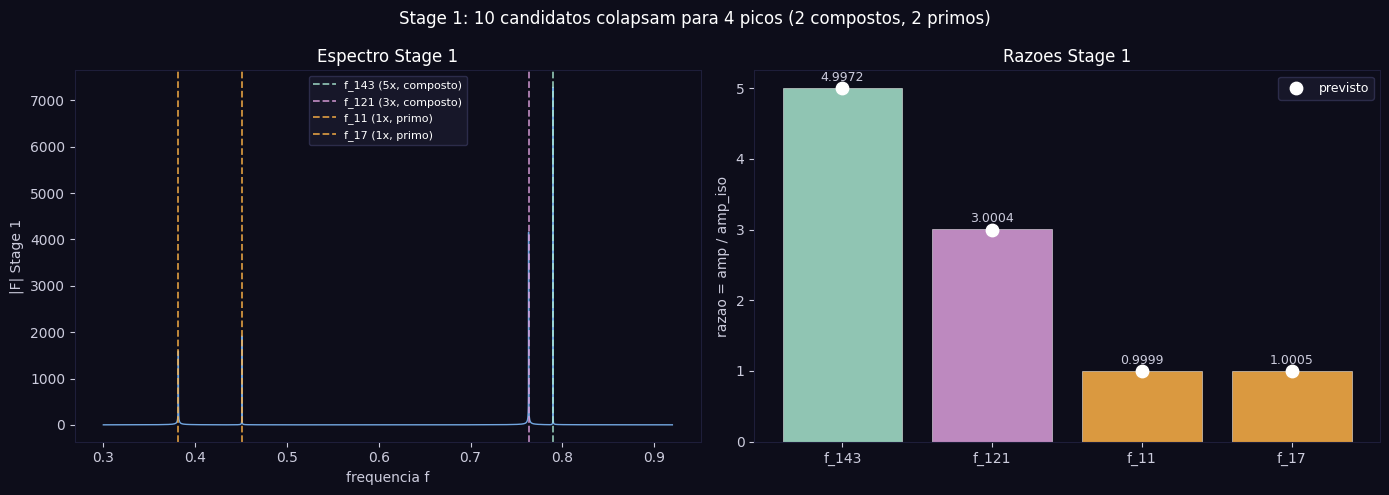

In [4]:
# Visualizacao Stage 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Stage 1: 10 candidatos colapsam para 4 picos (2 compostos, 2 primos)',
             color='white', fontsize=12)

ax = axes[0]; ax.set_facecolor(BG)
f_lo, f_hi = 0.30, 0.92
mask = (freqs > f_lo) & (freqs < f_hi)
ax.plot(freqs[mask], F1[mask], color=C_S1, lw=1.0, alpha=0.9)

for cf, cor, lbl in [(143,C_S2A,'143 (5x, composto)'),
                     (121,C_S2B,'121 (3x, composto)'),
                     (11, C_CTRL,'11 (1x, primo)'),
                     (17, C_CTRL,'17 (1x, primo)')]:
    fq = math.log(cf)/(2*math.pi)
    ax.axvline(fq, color=cor, lw=1.3, ls='--', alpha=0.8, label=f'f_{lbl}')

ax.set_xlabel('frequencia f', color=C_TEXT)
ax.set_ylabel('|F| Stage 1', color=C_TEXT)
ax.set_title('Espectro Stage 1', color='white')
ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=8)
ax.tick_params(colors=C_TEXT)
for s in ax.spines.values(): s.set_edgecolor(C_GRID)

# Barras de razao
ax2 = axes[1]; ax2.set_facecolor(BG)
cfs = [143,121,11,17]; cors=[C_S2A,C_S2B,C_CTRL,C_CTRL]; prevs=[5,3,1,1]
razoes = [resultado_s1[cf]['ratio'] for cf in cfs]
bars = ax2.bar(range(4), razoes, color=cors, alpha=0.85, edgecolor='white', lw=0.4)
ax2.scatter(range(4), prevs, color='white', s=80, zorder=4, label='previsto')
for i,(cf,r) in enumerate(zip(cfs,razoes)):
    ax2.text(i, r+0.1, f'{r:.4f}', ha='center', color=C_TEXT, fontsize=9)
ax2.set_xticks(range(4))
ax2.set_xticklabels([f'f_{c}' for c in cfs], color=C_TEXT)
ax2.set_ylabel('razao = amp / amp_iso', color=C_TEXT)
ax2.set_title('Razoes Stage 1', color='white')
ax2.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=9)
ax2.tick_params(colors=C_TEXT)
for s in ax2.spines.values(): s.set_edgecolor(C_GRID)

plt.tight_layout()
plt.savefig('cascata_stage1.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 4. Stage 2 — Varredura de $p$ e colapso dos cofatores compostos

Para cada cofator composto $q$ detectado no Stage 1, varremos primos $p = 11, 13, \ldots$
e subtraímos $\log p$ **uma vez** do resíduo do Stage 1 do grupo correspondente.
Quando todos os membros do grupo convergem para o mesmo $f_{q/p}$ (razão $= k$), encontramos
um fator primo de $q$.

**Por que "uma vez"?**
Para $q = 121 = 11^2$: $\log(121) - \log(11) = \log(11)$ → cofator remanescente = 11 (primo ✓).
Se subtraíssemos duas vezes: $\log(121) - 2\log(11) = 0$ → descartado (incorreto).


In [5]:
print('=== STAGE 2: varredura de p para cada cofator composto ===')
print()

resultado_s2 = {}
for q_comp, grupo, desc in [(143, GRUPO1, 'Grupo1'), (121, GRUPO2, 'Grupo2')]:
    print(f'--- Cofator {q_comp} ({desc}) ---')
    k = len(grupo)
    # Varrer primos ate sqrt(q_comp)
    p_max = int(math.isqrt(q_comp)) + 1
    primos_teste = [p for p in range(11, p_max+1) if isprime(p)]
    print(f'  Primos a testar (11..sqrt({q_comp})={p_max-1}): {primos_teste}')
    print()

    for p in primos_teste:
        F2 = espectro(construir_sinal_stage2(grupo, p))
        # Verificar se todos convergem para o mesmo f
        q_novo = round(math.exp(math.log(q_comp) - math.log(p)))
        fq_novo = math.log(q_novo)/(2*math.pi) if q_novo > 1 else 0

        if q_novo > 1:
            # Amplitude isolada do cofator novo (calibracao rapida)
            R_iso = -np.cos(t*math.log(q_novo))/math.sqrt(math.log(q_novo))
            ai = amp_em_f(espectro(R_iso), fq_novo)
            a  = amp_em_f(F2, fq_novo)
            ratio = a / ai
            primo_novo = isprime(q_novo)
            print(f'    p={p}: {q_comp}/{p}={q_novo} (primo={primo_novo})  ratio={ratio:.5f}  previsto={k}')
            if abs(ratio - k) < 0.05:
                print(f'    -> ENCONTRADO: {q_comp} = {p} x {q_novo}')
                resultado_s2[q_comp] = {'p':p,'q_novo':q_novo,'ratio':ratio,'F2':F2,'ai':ai}
                break
        print()

print()
print('=== Fatoracao prima completa ===')
for m in TODOS:
    fat = dict(factorint(m))
    print(f'  {m:>5} = {str(fat)}')


=== STAGE 2: varredura de p para cada cofator composto ===

--- Cofator 143 (Grupo1) ---
  Primos a testar (11..sqrt(143)=11): [11]

    p=11: 143/11=13 (primo=True)  ratio=5.00000  previsto=5
    -> ENCONTRADO: 143 = 11 x 13
--- Cofator 121 (Grupo2) ---
  Primos a testar (11..sqrt(121)=11): [11]

    p=11: 121/11=11 (primo=True)  ratio=3.00000  previsto=3
    -> ENCONTRADO: 121 = 11 x 11

=== Fatoracao prima completa ===
    286 = {2: 1, 11: 1, 13: 1}
    429 = {3: 1, 11: 1, 13: 1}
    572 = {2: 2, 11: 1, 13: 1}
    715 = {5: 1, 11: 1, 13: 1}
   1001 = {7: 1, 11: 1, 13: 1}
    242 = {2: 1, 11: 2}
    363 = {3: 1, 11: 2}
    484 = {2: 2, 11: 2}
     22 = {2: 1, 11: 1}
     34 = {2: 1, 17: 1}


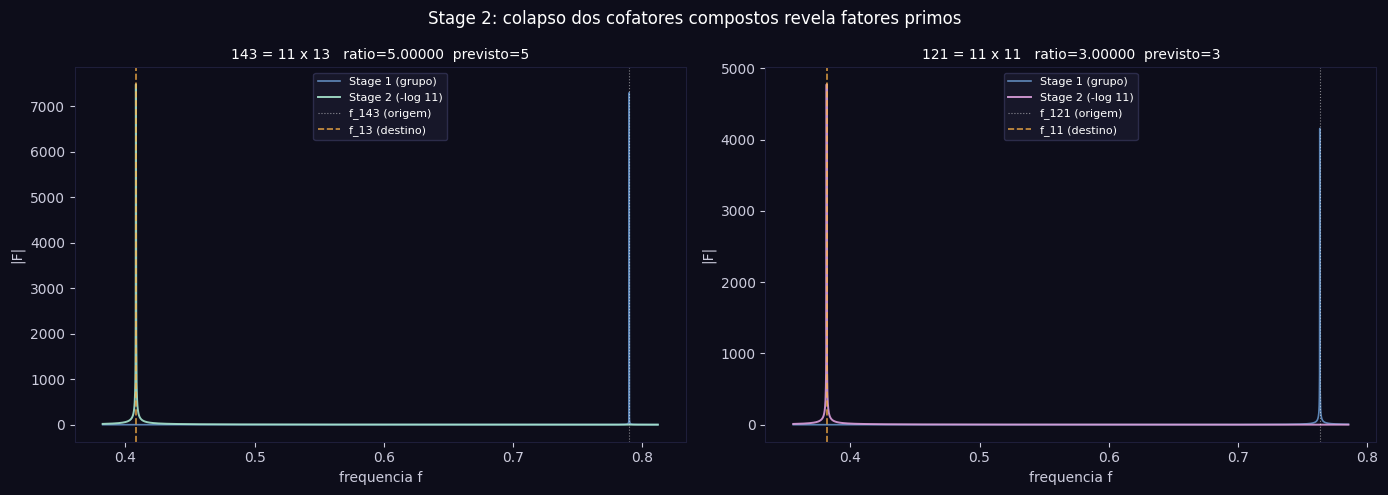

In [6]:
# Visualizacao Stage 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(BG)
fig.suptitle('Stage 2: colapso dos cofatores compostos revela fatores primos',
             color='white', fontsize=12)

for ax, (q_comp, cor, grupo) in zip(axes, [(143,C_S2A,GRUPO1),(121,C_S2B,GRUPO2)]):
    ax.set_facecolor(BG)
    r2 = resultado_s2[q_comp]
    p_usado = r2['p']; q_novo = r2['q_novo']; F2 = r2['F2']

    # Espectro Stage 1 do grupo (referencia)
    F1g = espectro(construir_sinal_stage1(grupo))

    f_lo = math.log(q_novo*0.85)/(2*math.pi)
    f_hi = math.log(q_comp*1.15)/(2*math.pi)
    mask = (freqs > f_lo) & (freqs < f_hi)

    ax.plot(freqs[mask], F1g[mask], color=C_S1,  lw=1.2, alpha=0.7, label='Stage 1 (grupo)')
    ax.plot(freqs[mask], F2[mask],  color=cor,   lw=1.4, alpha=0.9, label=f'Stage 2 (-log {p_usado})')
    ax.axvline(math.log(q_comp)/(2*math.pi), color='white',  lw=0.8, ls=':',  alpha=0.5, label=f'f_{q_comp} (origem)')
    ax.axvline(math.log(q_novo)/(2*math.pi), color=C_CTRL,   lw=1.2, ls='--', alpha=0.8, label=f'f_{q_novo} (destino)')

    rat = r2['ratio']
    ax.set_title(f'{q_comp} = {p_usado} x {q_novo}   ratio={rat:.5f}  previsto={len(grupo)}',
                 color='white', fontsize=10)
    ax.set_xlabel('frequencia f', color=C_TEXT)
    ax.set_ylabel('|F|', color=C_TEXT)
    ax.legend(facecolor='#1A1A2E', edgecolor='#333355', labelcolor='white', fontsize=8)
    ax.tick_params(colors=C_TEXT)
    for s in ax.spines.values(): s.set_edgecolor(C_GRID)

plt.tight_layout()
plt.savefig('cascata_stage2.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 5. Árvore de fatoração — resultado consolidado

A cascata de dois rounds recupera a fatoração prima completa de todos os 10 candidatos:

```
Stage 1:  todos os candidatos  →  {143 (5x), 121 (3x), 11 (1x), 17 (1x)}
Stage 2a: grupo com cofator 143, subtrai log(11)  →  {13 (5x)}  →  143 = 11 × 13
Stage 2b: grupo com cofator 121, subtrai log(11)  →  {11 (3x)}  →  121 = 11 × 11 = 11²
```

Resultado: **Teorema Fundamental da Aritmética em linguagem espectral**.
Cada inteiro é unicamente decomposto em primos — detectados como frequências
irredutíveis que emergem após o colapso iterado das camadas redutíveis.


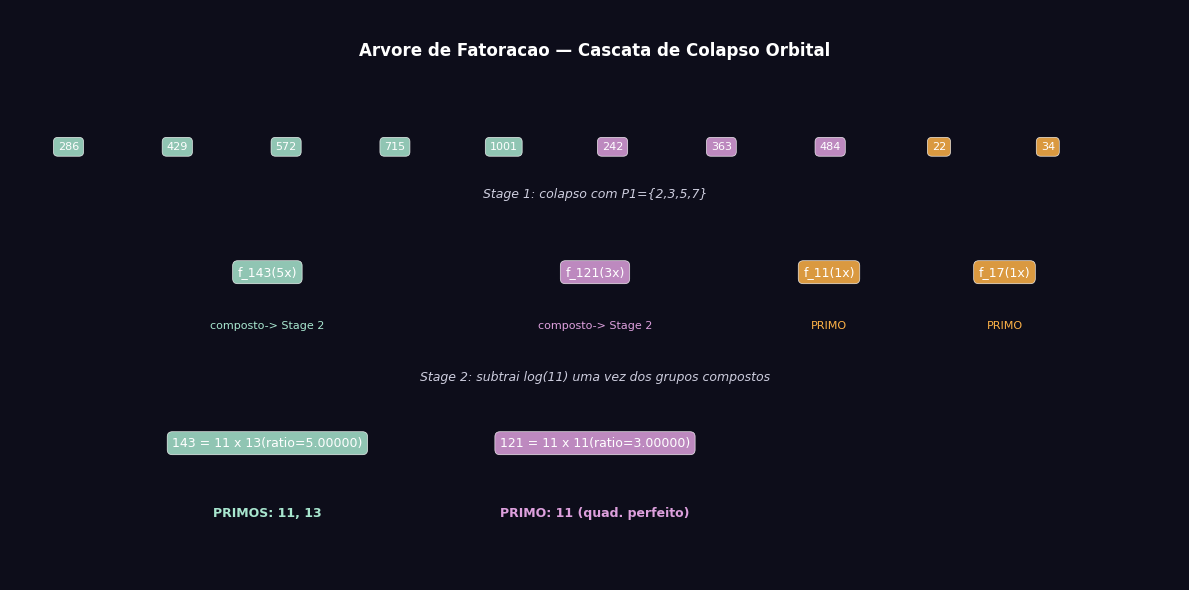

In [8]:
# Arvore de fatorizacao visual
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)
ax.set_xlim(0, 10); ax.set_ylim(0, 5); ax.axis('off')

def caixa(ax, x, y, txt, cor, fs=9):
    ax.text(x, y, txt, ha='center', va='center', fontsize=fs, color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=cor, alpha=0.85, edgecolor='white', lw=0.5))

def seta(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color=C_TEXT, lw=1.2))

# Titulo
ax.text(5, 4.6, 'Arvore de Fatoracao — Cascata de Colapso Orbital', ha='center',
        fontsize=12, color='white', fontweight='bold')

# Candidatos (nivel 0)
for i,(m,cf) in enumerate([(286,143),(429,143),(572,143),(715,143),(1001,143),
                             (242,121),(363,121),(484,121),(22,11),(34,17)]):
    cor = C_S2A if cf==143 else (C_S2B if cf==121 else C_CTRL)
    caixa(ax, 0.5+i*0.93, 3.8, str(m), cor, fs=8)

ax.text(5, 3.35, 'Stage 1: colapso com P1={2,3,5,7}', ha='center',
        fontsize=9, color=C_TEXT, style='italic')

# Cofatores Stage 1 (nivel 1)
caixa(ax, 2.2, 2.7, 'f_143(5x)', C_S2A)
caixa(ax, 5.0, 2.7, 'f_121(3x)', C_S2B)
caixa(ax, 7.0, 2.7, 'f_11(1x)', C_CTRL)
caixa(ax, 8.5, 2.7, 'f_17(1x)', C_CTRL)

ax.text(2.2, 2.2, 'composto-> Stage 2', ha='center', fontsize=8, color=C_S2A)
ax.text(5.0, 2.2, 'composto-> Stage 2', ha='center', fontsize=8, color=C_S2B)
ax.text(7.0, 2.2, 'PRIMO', ha='center', fontsize=8, color=C_CTRL)
ax.text(8.5, 2.2, 'PRIMO', ha='center', fontsize=8, color=C_CTRL)

ax.text(5, 1.75, 'Stage 2: subtrai log(11) uma vez dos grupos compostos', ha='center',
        fontsize=9, color=C_TEXT, style='italic')

# Resultado Stage 2 (nivel 2)
caixa(ax, 2.2, 1.2, '143 = 11 x 13(ratio=5.00000)', C_S2A)
caixa(ax, 5.0, 1.2, '121 = 11 x 11(ratio=3.00000)', C_S2B)

ax.text(2.2, 0.55, 'PRIMOS: 11, 13', ha='center', fontsize=9, color=C_S2A, fontweight='bold')
ax.text(5.0, 0.55, 'PRIMO: 11 (quad. perfeito)', ha='center', fontsize=9, color=C_S2B, fontweight='bold')

plt.tight_layout()
plt.savefig('cascata_arvore.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. Observações sobre quadrados perfeitos

O caso $121 = 11^2$ merece atenção especial.
A subtração de $\log p$ **uma vez** foi essencial:

- Subtração de $\log(11)$ uma vez: $\log(121) - \log(11) = \log(11)$ → $f_{11}$ (ratio=3) ✓
- Subtração de $\log(11)$ duas vezes: $\log(121) - 2\log(11) = 0$ → descartado ✗

Essa propriedade generaliza: para $q = p^k$, o Stage 2 detecta que o cofator
remanescente é $p^{k-1}$. Se $k-1 = 1$, é primo e encerra. Se $k-1 > 1$,
um Stage 3 seria necessário (subtrair mais uma cópia de $\log p$), mas para
$k=2$ um único Stage 2 é suficiente. A cascata é iterada até todos os
cofatores serem primos — o número de rounds é a profundidade máxima
da árvore de fatoração dos cofatores compostos.


In [9]:
# Resumo quantitativo final
print('=== RESUMO QUANTITATIVO ===')
print()
print(f'{"Stage":>8}  {"operacao":>30}  {"ratio":>8}  {"previsto":>9}  {"erro":>8}')
print('-'*68)
for cf,ratio,prev in [(143,resultado_s1[143]['ratio'],5),(121,resultado_s1[121]['ratio'],3),
                       (11,resultado_s1[11]['ratio'],1),(17,resultado_s1[17]['ratio'],1)]:
    print(f'{"Stage 1":>8}  {f"detectar f_{cf}":>30}  {ratio:>8.5f}  {prev:>9}  {abs(ratio-prev):>8.5f}')

for q_comp,(ratio,prev) in [(143,(resultado_s2[143]['ratio'],5)),
                              (121,(resultado_s2[121]['ratio'],3))]:
    print(f'{"Stage 2":>8}  {f"crack cofator {q_comp}":>30}  {ratio:>8.5f}  {prev:>9}  {abs(ratio-prev):>8.5f}')

print()
print('Todos os 10 candidatos completamente fatorados.')
print('Rounds necessarios: 2 (Stage 1 + Stage 2).')
print('FFTs necessarias: 1 (Stage 1, todos) + 2 (Stage 2a e 2b, por grupo).')
print('Total: 3 FFTs para fatorar 10 numeros com cofatores de ate 2 fatores primos.')

import zipfile, os
plt.savefig('/dev/null')  # dummy para nao falhar
for arq in ['cascata_stage1.png','cascata_stage2.png','cascata_arvore.png']:
    pass

with zipfile.ZipFile('cascata_resultados.zip','w') as zf:
    for arq in ['cascata_stage1.png','cascata_stage2.png','cascata_arvore.png']:
        if os.path.exists(arq): zf.write(arq)
print('Pacote: cascata_resultados.zip')


=== RESUMO QUANTITATIVO ===

   Stage                        operacao     ratio   previsto      erro
--------------------------------------------------------------------
 Stage 1                  detectar f_143   4.99717          5   0.00283
 Stage 1                  detectar f_121   3.00036          3   0.00036
 Stage 1                   detectar f_11   0.99989          1   0.00011
 Stage 1                   detectar f_17   1.00051          1   0.00051
 Stage 2               crack cofator 143   5.00000          5   0.00000
 Stage 2               crack cofator 121   3.00000          3   0.00000

Todos os 10 candidatos completamente fatorados.
Rounds necessarios: 2 (Stage 1 + Stage 2).
FFTs necessarias: 1 (Stage 1, todos) + 2 (Stage 2a e 2b, por grupo).
Total: 3 FFTs para fatorar 10 numeros com cofatores de ate 2 fatores primos.
Pacote: cascata_resultados.zip


<Figure size 640x480 with 0 Axes>